In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles, venn2
import numpy as np

In [2]:
excel_file = "../../DataFiles/EPZ_against_Control.xlsx"  
EPZdf = pd.read_excel(excel_file, index_col = 'EnsembleID')

excel_file = "../../DataFiles/GSK_against_control.xlsx"  
GSKdf = pd.read_excel(excel_file, index_col = 'EnsembleID')

excel_file = "../../DataFiles/UNC_against_Control.xlsx"  
UNCdf = pd.read_excel(excel_file, index_col = 'EnsembleID')

print(len(EPZdf))
print(len(GSKdf))
print(len(UNCdf))

60664
60664
60664


In [3]:
UpRegEPZdf = EPZdf[(EPZdf.Log2FC > 1) & (EPZdf.Adj_p < 0.05)]
UpRegGSKdf = GSKdf[(GSKdf.Log2FC > 1) & (GSKdf.Adj_p < 0.05)]
UpRegUNCdf = UNCdf[(UNCdf.Log2FC > 1) & (UNCdf.Adj_p < 0.05)]

print(UpRegEPZdf.loc[UpRegEPZdf['Adj_p'].idxmax()])
print(len(UpRegEPZdf))
print(len(UpRegGSKdf))
print(len(UpRegUNCdf))

Gene           CYP24A1
BaseMean     48.206386
Log2FC        1.105681
StdErr        0.411762
Wald-stat      2.68524
p-value       0.007248
Adj_p         0.049193
Name: ENSG00000019186, dtype: object
623
2297
391


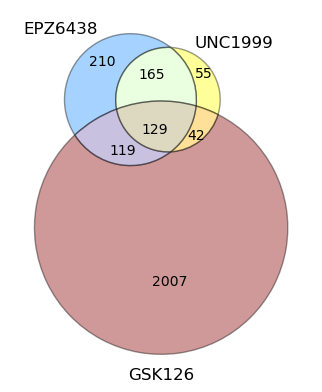

In [4]:
# Convert to sets
EPZ_set = set(UpRegEPZdf.index)
GSK_set = set(UpRegGSKdf.index)
UNC_set = set(UpRegUNCdf.index)

ThreeDrugs = venn3([EPZ_set, UNC_set, GSK_set], 
             set_labels=('EPZ6438', 'UNC1999', 'GSK126'),
             set_colors=('dodgerblue', 'yellow', 'darkred'))

# Modify the linestyle and linewidth of each circle
for patch in ThreeDrugs.patches:
    if patch:  # Check if the patch (circle) exists
        patch.set_edgecolor('black')  # Set the edge color to black
        patch.set_linestyle("solid")  # Set the linestyle to dashed
        patch.set_linewidth(1)  # Set the linewidth to 2

plt.savefig("ThreeDrugVenn.pdf", format="pdf")

In [5]:
common_genes = EPZ_set & GSK_set & UNC_set
common_genes_list = list(common_genes)

# Filter the original dataframe to include only the common genes
common_genes_info_df = EPZdf.loc[common_genes_list]
print(common_genes_info_df)
common_genes_set = set(common_genes_info_df.Gene)
# Display the new DataFrame with full information

ChIP_seq_txt = pd.read_csv('../../DataFiles/ChIP-seq.txt', header=None)

# Convert the DataFrame into a Python set
ChIP_seq_set = set(ChIP_seq_txt[0].tolist())


                     Gene    BaseMean    Log2FC    StdErr  Wald-stat  \
EnsembleID                                                             
ENSG00000166206    GABRB3   37.182505  1.966128  0.458879   4.284631   
ENSG00000165349    SLC7A3  125.843517  1.916946  0.295769   6.481238   
ENSG00000125355  TMEM255A  137.617077  1.288029  0.368480   3.495521   
ENSG00000177614     PGBD5  210.011843  1.536980  0.239085   6.428606   
ENSG00000143061     IGSF3  862.649602  1.593402  0.171840   9.272586   
...                   ...         ...       ...       ...        ...   
ENSG00000166257     SCN3B   75.999185  2.455959  0.462312   5.312340   
ENSG00000196542    SPTSSB   39.834318  1.492108  0.430396   3.466825   
ENSG00000204103      MAFB  340.181622  1.138084  0.173023   6.577638   
ENSG00000136842     TMOD1  160.404448  1.701221  0.246442   6.903117   
ENSG00000163888   CAMK2N2  373.677602  1.550980  0.246658   6.287982   

                      p-value         Adj_p  
EnsembleID       

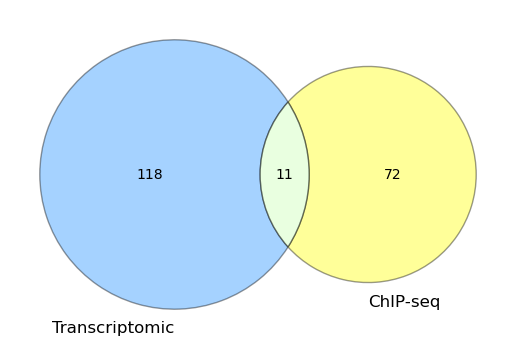

In [6]:
TanscripVSChIP = venn2([common_genes_set, ChIP_seq_set], 
             set_labels=('Transcriptomic', 'ChIP-seq'),
             set_colors=('dodgerblue', 'yellow'))

# Modify the linestyle and linewidth of each circle
for patch in TanscripVSChIP.patches:
    if patch:  # Check if the patch (circle) exists
        patch.set_edgecolor('black')  # Set the edge color to black
        patch.set_linestyle("solid")  # Set the linestyle to dashed
        patch.set_linewidth(1)  # Set the linewidth to 2

plt.show()

In [7]:
ChipSharedTranscriptomic = common_genes_set.intersection(ChIP_seq_set)

# Print the common genes
print("Common genes:", ChipSharedTranscriptomic)

Common genes: {'SAMD14', 'UNC13A', 'NKD1', 'SSTR2', 'SH3PXD2A', 'NRXN2', 'MAP6', 'HTRA3', 'C11orf96', 'DRAXIN', 'EFNA2'}


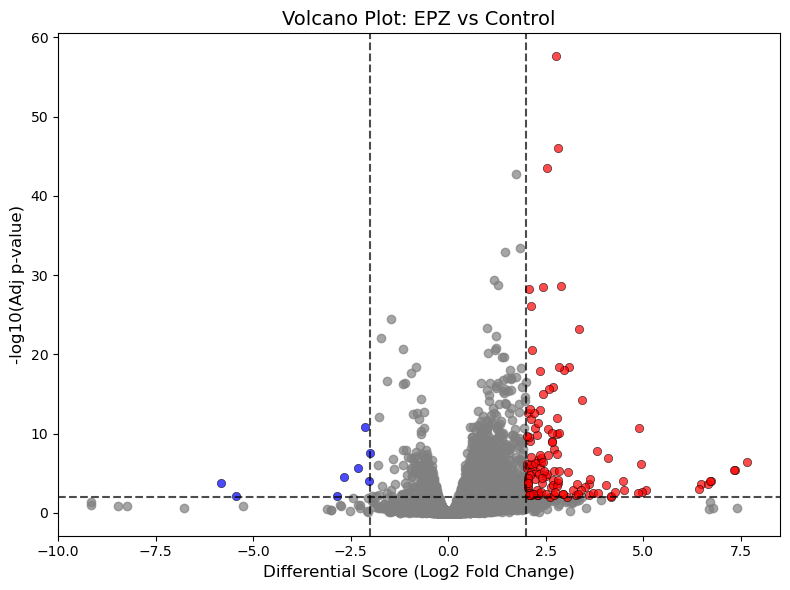

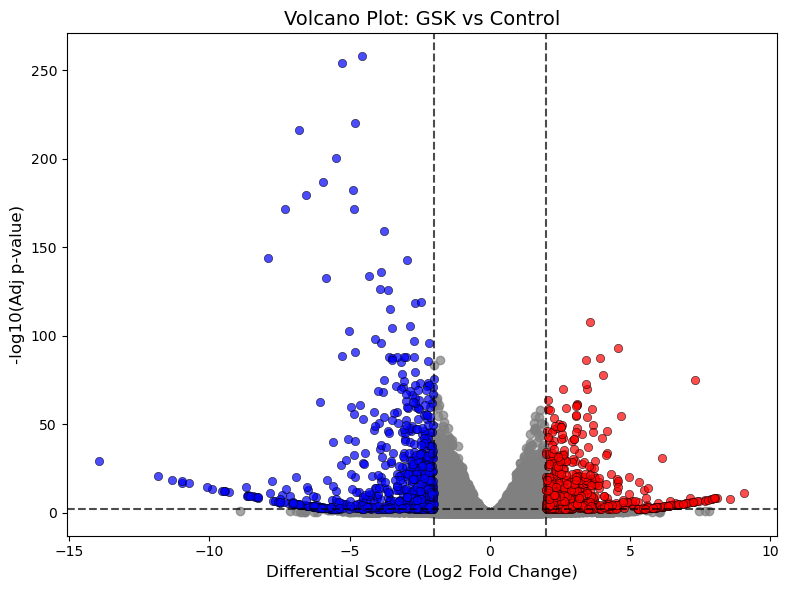

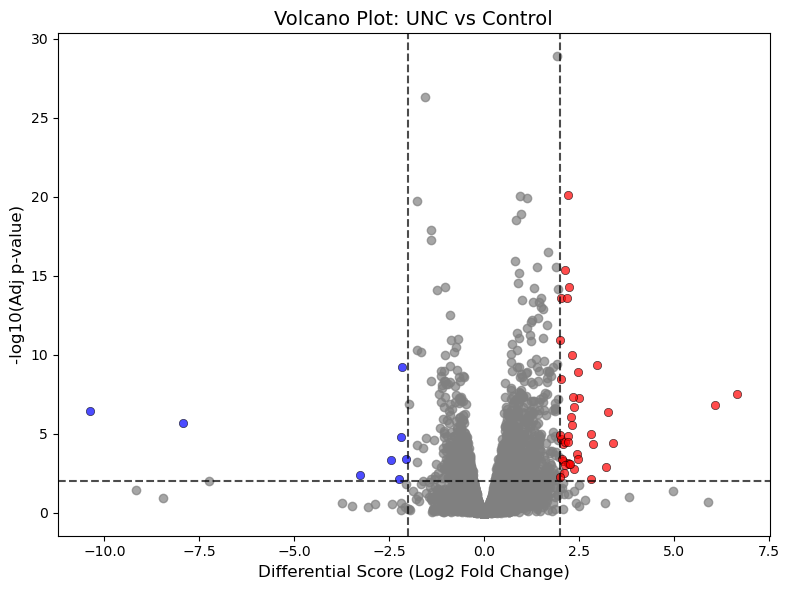

In [18]:

# Function to create a volcano plot
def volcano_plot(df, title, output_file):
    plt.figure(figsize=(8, 6))

    # Drop rows with NaN or 0 values for Log2FC and Adj_p
    df = df.dropna(subset=['Log2FC', 'Adj_p'])
    df = df[(df['Log2FC'] != 0) & (df['Adj_p'] != 0)]

    # Compute -log10(Adj_p)
    df['-log10(Adj_p)'] = -np.log10(df['Adj_p'])

    # Split the dataframe into significant and non-significant subsets
    sig_up = df[(df['Adj_p'] < 0.01) & (df['Log2FC'] > 2)]
    sig_down = df[(df['Adj_p'] < 0.01) & (df['Log2FC'] < -2)]
    non_sig = df[~((df['Adj_p'] < 0.01) & (np.abs(df['Log2FC']) > 2))]

    # Plot non-significant points (grey, no border)
    plt.scatter(non_sig['Log2FC'], non_sig['-log10(Adj_p)'], c='grey', alpha=0.7)

    # Plot significant points (red and blue with black borders)
    plt.scatter(sig_up['Log2FC'], sig_up['-log10(Adj_p)'], c='red', edgecolor='black', linewidth=0.5, alpha=0.7)
    plt.scatter(sig_down['Log2FC'], sig_down['-log10(Adj_p)'], c='blue', edgecolor='black', linewidth=0.5, alpha=0.7)

    # Add dashed thresholds
    plt.axvline(x=2, linestyle="--", color="black", alpha=0.7)  # Upregulation threshold
    plt.axvline(x=-2, linestyle="--", color="black", alpha=0.7)  # Downregulation threshold
    plt.axhline(y=-np.log10(0.01), linestyle="--", color="black", alpha=0.7)  # Significance threshold

    # Set labels, title, and limits
    plt.xlabel("Differential Score (Log2 Fold Change)", fontsize=12)
    plt.ylabel("-log10(Adj p-value)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(False)

    # Save as a PDF
    plt.tight_layout()
    plt.savefig(output_file, format='pdf')

    # Display the plot
    plt.show()

# Create volcano plots and save as PDFs
volcano_plot(EPZdf, "Volcano Plot: EPZ vs Control", "EPZ_vs_Control.pdf")
volcano_plot(GSKdf, "Volcano Plot: GSK vs Control", "GSK_vs_Control.pdf")
volcano_plot(UNCdf, "Volcano Plot: UNC vs Control", "UNC_vs_Control.pdf")